# Performing Causal Tasks with DoWhy

- This notebook teaches how to use causal inference to answer real-world questions
  - Estimating causal effects using multiple identification strategies
  - Quantifying the strength of causal relationships
  - Explaining system behavior through causal mechanisms
  - Answering counterfactual and policy questions
  - Making robust predictions under distribution shift

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

# Third-party libraries.
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Helpers imports.
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook
import helpers.hgraphviz as hgraphviz

# Notebook-specific utilities.
import dowhy_03_causal_tasks_utils as utils

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

_LOG = logging.getLogger(__name__)

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
hdbg.init_logger(verbosity=logging.INFO, use_exec_path=False)

_LOG.info("Notebook initialized")

INFO  > cmd='/opt/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-ab07fc8c-58c7-4736-b484-eb55d186317d.json'
INFO  Notebook initialized


# Part 1: Estimating Causal Effects

- The **fundamental problem of causal inference**: "we can't observe multiple potential outcomes at the same time"
- Learn strategies to estimate causal effects from observational data
  - Backdoor adjustment: condition on confounders
  - Instrumental variables: use exogenous variation
  - Graphical causal models: use fitted mechanisms
  - Randomized-controlled trials: exploit as-if-random assignment

## Cell 1.1: The Fundamental Problem of Causal Inference

In [ ]:
#utils.cell1_1_plot_potential_outcomes??

In this cell, we demonstrate the fundamental challenge of causal inference using a
**confounded healthcare scenario**.

**Data Generation Process:**
- Exogenous variable: `Severity` (disease severity) is randomly generated
- Confounder: Severity causes both treatment assignment and outcome
  - Patients with higher severity are more likely to receive treatment
  - Patients with higher severity have worse outcomes regardless of treatment
- Treatment: `Severity → Treatment assignment` (not randomized)
- Outcome: `Severity + Treatment → Outcome` (true treatment effect ≈ 10)

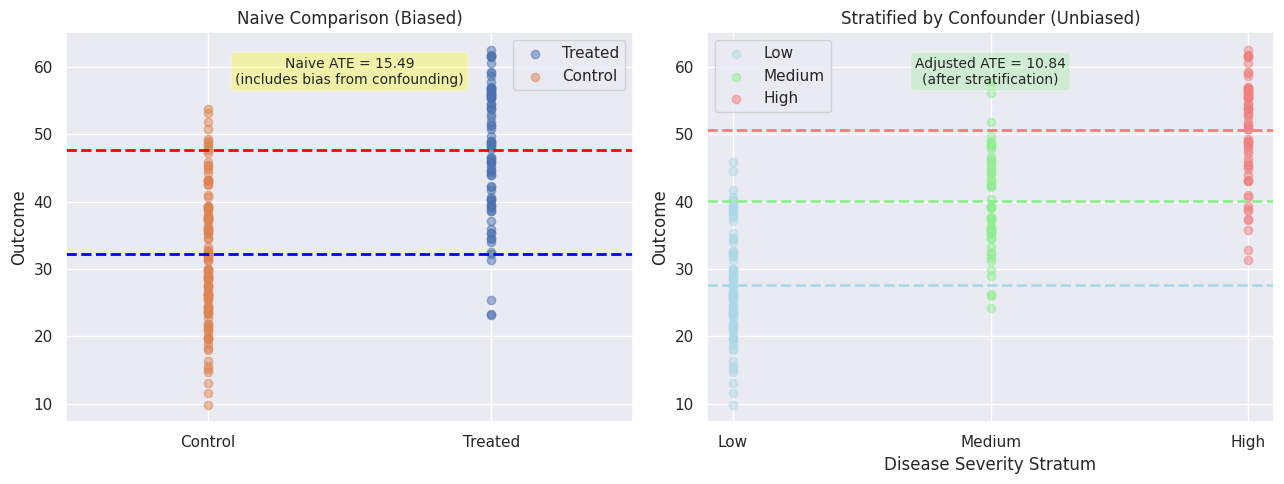

In [3]:
# TODO(ai_gp): Use plot_causal_dag to plot the DAG
utils.cell1_1_plot_potential_outcomes()

Visualize the fundamental problem of causal inference using confounded healthcare data
- Left panel: naive comparison showing biased ATE due to disease severity confounding.
- Right panel: adjusted comparison using stratification to remove bias and recover true effect.

Severity is a **confounder** that opens a backdoor path:
  `Treatment ← Severity → Outcome`

**Why this matters:**
- Naive comparison (treated vs control) is **biased** because treated units tend to have
  higher severity
- Solution: **Adjust for confounders** (stratification, regression, matching, IPW)
  to break the backdoor path and estimate causal effects consistently

## Cell 1.2: Backdoor Criterion and Confounding

In [4]:
# Generate healthcare dataset with confounded treatment.
# TODO(ai_gp): Use plot_causal_dag to plot the causal DAG generating the data
df_health, G_health = utils.cell1_2_healthcare_dataset(n_samples=500)

# TODO(ai_gp): Fix this function.
utils.cell1_2_plot_backdoor_dag(G_health)

AttributeError: module 'dowhy_03_causal_tasks_utils' has no attribute 'cell1_2_plot_backdoor_dag'

In [ ]:
display(df_health.head())
print(f"\nDataset shape: {df_health.shape}")

In [5]:
# Compute naive ATE and show the bias.
naive_ate = utils.cell1_2_compute_naive_ate(df_health)
print(f"Naive ATE (biased): {naive_ate:.3f}")
print("This estimate is biased because severity confounds the medication-recovery relationship.")

Naive ATE (biased): 0.259
This estimate is biased because severity confounds the medication-recovery relationship.


In [7]:
# Interactive widget: compare different adjustment methods.
# TODO(ai_gp): cell1_2_interactive_adjustment_methods crashes for ipw
utils.cell1_2_interactive_adjustment_methods(df_health)

## Cell 1.3: Natural Experiments and Instrumental Variables

In [9]:
# Generate education-earnings dataset with unobserved ability.
# TODO(ai_gp): Use plot_causal_dag to plot the causal DAG generating the data
df_edu, G_edu = utils.cell1_3_education_earnings_dataset(n_samples=500)

display(df_edu.head())
print(f"\nNote: Ability is unobserved; Distance is the instrument.")

,Distance,Education,Earnings
0,64.591724,0,34417.450029
1,57.077830,1,31470.261012
2,35.609673,0,44896.663785
3,98.651525,1,87925.594715
4,60.577482,0,25286.577948



Note: Ability is unobserved; Distance is the instrument.


In [11]:
# Compute 2SLS estimate of education effect on earnings.
# TODO(ai_gp): explain the compute two-stage least squares (2SLS/IV estimator).
iv_results = utils.cell1_3_compute_2sls(df_edu)
print(f"First-stage coefficient (Distance → Education): {iv_results['first_stage']:.3f}")
print(f"2SLS estimate (LATE): {iv_results['late']:.0f}")
print(f"True effect: ~15000 (education increases earnings by ~$15k)")

First-stage coefficient (Distance → Education): -0.003
2SLS estimate (LATE): 21492
True effect: ~15000 (education increases earnings by ~$15k)


In [12]:
# Interactive widget: explore IV strength sensitivity.
utils.cell1_3_interactive_iv_strength(df_edu)

## Cell 1.4: Natural Experiments and Quasi-Experimental Designs

In [ ]:
# Generate policy intervention dataset.
df_did = utils.cell1_4_policy_dataset(n_units=200, n_periods=3)

display(df_did.head(10))

In [ ]:
# Visualize the DiD trends.
utils.cell1_4_plot_did_trends(df_did)

In [ ]:
# Compute difference-in-differences estimate.
did_estimate = utils.cell1_4_compute_did(df_did)
print(f"DiD estimate: {did_estimate:.2f}")
print(f"True treatment effect: ~15 (policy increases outcome by 15 units)")
print(f"The estimate is valid if the parallel trends assumption holds.")

## Cell 1.5: Conditional Average Treatment Effects (CATE)

In [ ]:
# Estimate CATE by disease severity.
cate_df = utils.cell1_5_estimate_cate(df_health, by_var="Severity", n_groups=3)

display(cate_df)

In [ ]:
# Plot treatment effect heterogeneity.
utils.cell1_5_plot_cate_heterogeneity(cate_df)

In [ ]:
# Interactive tool: predict treatment effect for specific patient profile.
utils.cell1_5_interactive_patient_profile(df_health)

## Cell 1.6: Causal Effects Using Graphical Causal Models

In [ ]:
# Generate synthetic dataset from known SCM.
df_scm, G_scm = utils.cell1_6_synthetic_scm_dataset(n_samples=300)

display(df_scm.head())

In [ ]:
# Estimate treatment effect via GCM (do-calculus).
gcm_results = utils.cell1_6_estimate_effect_via_gcm(df_scm, G_scm)
print(f"GCM-based ATE (X → Y): {gcm_results['ate']:.3f}")
print(f"E[Y | do(X=1)]: {gcm_results['mean_y_do_1']:.3f}")
print(f"E[Y | do(X=0)]: {gcm_results['mean_y_do_0']:.3f}")

In [ ]:
# Compare estimates across different methods.
comparison_df = utils.cell1_6_compare_methods(df_scm, G_scm)

display(comparison_df)

# Part 2: Quantifying Causal Influence

- Move beyond average effects to understand system structure
- Learn which variables most influence others
- Quantify strength of individual causal arrows
- Measure how much of variable's behavior is determined vs. stochastic

## Cell 2.1: Mediation Analysis – Direct vs. Indirect Effects

In [ ]:
# Generate education-earnings-experience dataset.
df_mediation, G_mediation = utils.cell2_1_mediation_dataset(n_samples=400)

display(df_mediation.head())

In [ ]:
# Estimate mediation effects.
med_results = utils.cell2_1_estimate_mediation(df_mediation)
print(f"Natural Direct Effect (NDE): {med_results['nde']:.0f}")
print(f"Natural Indirect Effect (NIE): {med_results['nie']:.0f}")
print(f"Total Effect: {med_results['total_effect']:.0f}")
print(f"Percent Mediated: {med_results['pct_mediated']:.1f}%")

In [ ]:
# Visualize mediation pathways.
utils.cell2_1_plot_mediation_pathways(df_mediation, med_results)

## Cell 2.2: Direct Effect / Quantifying Arrow Strength

In [ ]:
# Generate supply chain dataset.
df_supply, G_supply = utils.cell2_2_supply_chain_dataset(n_samples=300)

display(df_supply.head())

In [ ]:
# Estimate arrow strengths for each causal edge.
arrow_strengths = utils.cell2_2_estimate_arrow_strengths(df_supply, G_supply)

print("Arrow Strengths (regression coefficients):")
for (parent, child), strength in arrow_strengths.items():
    print(f"  {parent} → {child}: {strength:.4f}")

In [ ]:
# Plot weighted DAG with arrows colored/sized by strength.
utils.cell2_2_plot_weighted_dag(G_supply, arrow_strengths)

## Cell 2.3: Intrinsic Causal Influence (ICC)

In [ ]:
# Compute intrinsic causal influence for each node.
icc_scores = utils.cell2_3_compute_icc(df_supply, G_supply)

print("Intrinsic Causal Influence (R² of fit):")
for node, icc in icc_scores.items():
    print(f"  {node}: {icc:.3f}")

In [ ]:
# Visualize nodes colored by ICC.
utils.cell2_3_plot_icc(G_supply, icc_scores)

# Part 3: Root-Cause Analysis and Explanation

- When things go wrong: what caused the problem?
- Trace anomalies back through causal mechanisms
- Decompose distributional shifts into feature contributions
- Distinguish causally relevant features from proxy variables

## Cell 3.1: Anomaly Attribution

In [ ]:
# Generate system metrics dataset.
df_sys, G_sys = utils.cell3_1_system_metrics_dataset(n_samples=200)

display(df_sys.head())

In [ ]:
# Inject an anomaly and attribute it.
baseline, anomaly = utils.cell3_1_inject_anomaly(df_sys)

print("Baseline conditions (normal operation):")
for var in ["CpuUsage", "MemoryUsage", "NetworkLatency"]:
    print(f"  {var}: {baseline[var]:.1f}")

print("\nAnomaly values:")
for var in ["CpuUsage", "MemoryUsage", "NetworkLatency"]:
    print(f"  {var}: {anomaly[var]:.1f}")

In [ ]:
# Interactive anomaly attribution dashboard.
utils.cell3_1_interactive_anomaly_dashboard(df_sys, G_sys)

## Cell 3.2: Attributing Distributional Changes

In [ ]:
# Generate before/after customer datasets with distributional shift.
df_before, df_after = utils.cell3_2_customer_shift_dataset()

print("Before: Younger, lower-income customers")
print(f"  Mean Age: {df_before['Age'].mean():.1f}, Mean Satisfaction: {df_before['Satisfaction'].mean():.2f}")

print("\nAfter: Older, higher-income customers")
print(f"  Mean Age: {df_after['Age'].mean():.1f}, Mean Satisfaction: {df_after['Satisfaction'].mean():.2f}")

In [ ]:
# Compute distribution shift attribution.
shift_results = utils.cell3_2_compute_shift_attribution(df_before, df_after)

display(shift_results)

In [ ]:
# Visualize shift attribution.
utils.cell3_2_plot_shift_attribution(shift_results)

## Cell 3.3: Feature Relevance in Causal Context

In [ ]:
# Generate loan dataset with proxy variable.
df_loan, G_loan = utils.cell3_3_loan_dataset(n_samples=400)

display(df_loan.head())

In [ ]:
# Compute causal relevance for each feature.
causal_rel = utils.cell3_3_compute_causal_relevance(df_loan, G_loan)

print("Causal Relevance (direct effects):")
display(causal_rel)

In [ ]:
# Compute statistical relevance for comparison.
stat_rel = utils.cell3_3_compute_statistical_relevance(df_loan)

print("Statistical Relevance (correlations):")
display(stat_rel)

In [ ]:
# Compare causal vs. statistical importance side-by-side.
utils.cell3_3_plot_causal_vs_statistical(causal_rel, stat_rel)

# Part 4: Answering What-If Questions

- Use causal models to predict outcomes under hypothetical interventions
- Design optimal policies by understanding heterogeneous treatment effects
- Make robust recommendations for decision-making

## Cell 4.1: Simulating Impact of Interventions

In [ ]:
# Generate marketing dataset.
df_marketing, G_marketing = utils.cell4_1_marketing_dataset(n_samples=300)

display(df_marketing.head())

In [ ]:
# Simulate dose-response curve.
dose_response = utils.cell4_1_simulate_dose_response(df_marketing, G_marketing)

display(dose_response)

In [ ]:
# Plot dose-response curve.
utils.cell4_1_plot_dose_response(dose_response)

In [ ]:
# Interactive widget to explore interventions.
utils.cell4_1_interactive_intervention(df_marketing, G_marketing)

## Cell 4.2: Computing Counterfactuals

In [ ]:
# Interactive tool for individual counterfactual analysis.
utils.cell4_2_interactive_counterfactual(df_sys, G_sys)

## Cell 4.3: Optimal Policy Estimation

In [ ]:
# Generate customer support dataset.
df_support, G_support = utils.cell4_3_customer_support_dataset(n_samples=300)

display(df_support.head())

In [ ]:
# Plot actual vs. optimal treatment allocation.
utils.cell4_3_plot_policy_comparison(df_support)

In [ ]:
# Interactive widget for exploring policy thresholds.
utils.cell4_3_interactive_policy(df_support)

# Part 5: Causal Prediction

- ML models fail under distribution shift; causal models are more robust
- Learn when to trust causal predictions for out-of-distribution data
- Understand transportability: when do results generalize across populations?

## Cell 5.1: Predicting Outcomes for Out-of-Distribution Inputs

In [ ]:
# Generate training and OOD test datasets.
df_train, df_test = utils.cell5_1_generate_ood_data(n_train=300, n_test=100)

print(f"Training data range: X ∈ [{df_train['X'].min():.2f}, {df_train['X'].max():.2f}]")
print(f"Test data range (OOD): X ∈ [{df_test['X'].min():.2f}, {df_test['X'].max():.2f}]")

In [ ]:
# Fit ML and causal models.
ml_params, causal_params = utils.cell5_1_fit_ml_and_causal_models(df_train)

print(f"Fitted models:")
print(f"  Intercept: {ml_params['intercept']:.2f}")
print(f"  Slope: {ml_params['slope']:.2f}")

In [ ]:
# Compare predictions on OOD data.
perf_df = utils.cell5_1_compare_ood_predictions(df_test, ml_params, causal_params)

display(perf_df)

In [ ]:
# Plot OOD prediction comparison.
utils.cell5_1_plot_ood_comparison(df_train, df_test)

## Cell 5.2: Transportability and Generalization

In [ ]:
# Generate datasets from two populations with different distributions.
pop_a, pop_b = utils.cell5_2_two_population_dataset()

print("Population A: Mean age = {:.1f}".format(pop_a['Age'].mean()))
print("Population B: Mean age = {:.1f}".format(pop_b['Age'].mean()))

In [ ]:
# Interactive widget comparing populations.
utils.cell5_2_interactive_population_comparison(pop_a, pop_b)

# Part 6: Integration and Application

- Synthesize understanding of all methods
- Learn when to apply each method to real problems
- Run complete end-to-end causal analysis

## Cell 6.1: Choosing the Right Method for Your Causal Question

In [13]:
# Interactive decision tree for method selection.
utils.cell6_1_interactive_decision_tree()

## Cell 6.2: Comprehensive Case Study – End-to-End Causal Analysis

In [ ]:
# Generate e-commerce dataset.
df_ecommerce, G_ecommerce = utils.cell6_2_ecommerce_dataset(n_samples=500)

display(df_ecommerce.head())

In [ ]:
# Run comprehensive causal analysis.
analysis_results = utils.cell6_2_run_full_analysis(df_ecommerce, G_ecommerce)

print("Case Study: E-Commerce Marketing ROI")
print(f"  Regression-based ATE: {analysis_results['regression_ate']:.2f}")
print(f"  GCM-based ATE: {analysis_results['gcm_ate']:.2f}")
print(f"  Estimates are similar, suggesting robust effect")

In [ ]:
# Plot comprehensive summary.
utils.cell6_2_plot_case_study_summary(analysis_results)

## Cell 6.3: Limitations, Assumptions, and When Causal Methods Fail